# code from github
https://github.com/cheminfo-py/xrd-tools/blob/master/xrd_tools/laue_predictor.py

**to use SG in pytgen i don't know but GSAS has it**  
GSASIIpwd.getHKLpeak  
https://gsas-ii.readthedocs.io/en/latest/GSASIIpwd.html#GSASIIpwd.getHKLpeak

https://www.cryst.ehu.es/cryst/get_hkl.html

single cell, later there's the divided codes

In [28]:
from pymatgen.core import Lattice, Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from math import sin, asin, degrees, radians
import numpy as np
from pymatgen.analysis.diffraction.core import (
    AbstractDiffractionPatternCalculator,
    DiffractionPattern,
    get_unique_families,
    
)
from pymatgen.analysis.diffraction.xrd import WAVELENGTHS

# Define the lattice parameters
a = 1  # Lattice parameter a
b = 1  # Lattice parameter b
c = 1  # Lattice parameter c
alpha = 90  # Lattice angle alpha in degrees
beta = 90  # Lattice angle beta in degrees
gamma = 90  # Lattice angle gamma in degrees
sg = 'Pa-3'

# Create the lattice
lattice = Lattice.from_parameters(a, b, c, alpha, beta, gamma)
wavelength = 1.5447
is_hex = lattice.is_hexagonal()

two_theta_range = (1,110)
TWO_THETA_TOL = 0.1

# Obtained from Bragg condition. Note that reciprocal lattice
# vector length is 1 / d_hkl.
min_r_sphere, max_r_sphere = (
    (0, 2 / wavelength)
    if two_theta_range is None
    else [2 * sin(radians(t / 2)) / wavelength for t in two_theta_range]
)

# Obtain crystallographic reciprocal lattice points within range
recip_latt = lattice.reciprocal_lattice_crystallographic
recip_pts = recip_latt.get_points_in_sphere([[0, 0, 0]], [0, 0, 0], max_r_sphere)
if min_r_sphere:
    recip_pts = [pt for pt in recip_pts if pt[1] >= min_r_sphere]

peaks = {}
two_thetas = []

for hkl, s_hkl, index, _ in sorted(
    recip_pts, key=lambda i: (i[1], -i[0][0], -i[0][1], -i[0][2])):
    # Force miller indices to be integers.
    hkl = [int(round(i)) for i in hkl]
    if s_hkl != 0:

        d_hkl = 1 / s_hkl

        # Bragg condition
        theta = asin(wavelength * s_hkl / 2)

        two_theta = degrees(2 * theta)

        if is_hex:
            # Use Miller-Bravais indices for hexagonal lattices.
            hkl = (hkl[0], hkl[1], -hkl[0] - hkl[1], hkl[2])
        
        # Deal with floating point precision issues.
        index = np.where(
            np.abs(np.subtract(two_thetas, two_theta))
            < TWO_THETA_TOL
        )
        if len(index[0]) > 0:
            peaks[two_thetas[index[0][0]]][0] += 1.0
            peaks[two_thetas[index[0][0]]][1].append(tuple(hkl))
        else:
            peaks[two_theta] = [1.0, [tuple(hkl)], d_hkl]
            two_thetas.append(two_theta)

x = []
y = []
hkls = []
d_hkls = []
for k in sorted(peaks.keys()):
    peak_data = peaks[k]
    fam = get_unique_families(peak_data[1])
    print(f'peaks: {peak_data}, peak_dict: {k}, families: {fam}')
    
    x.append(k)
    y.append(peak_data[0])
    hkls.append(
        [{"hkl": hkl, "multiplicity": mult} for hkl, mult in fam.items()]
    )
    d_hkls.append(peak_data[2])

peaks: [6.0, [(1, 0, 0), (0, 1, 0), (0, 0, 1), (0, 0, -1), (0, -1, 0), (-1, 0, 0)], 1.0], peak_dict: 101.13077671521653, families: {(1, 0, 0): 6}


In [29]:
hkls[:5]

[[{'hkl': (1, 0, 0), 'multiplicity': 6}]]

In [30]:
d_hkls[:5]

[1.0]

In [31]:
[wavelength/(2*d_hkl) for d_hkl in d_hkls][:5]

[0.77235]

# Extapolate single informations

In [2]:
from pymatgen.core import Lattice, Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.symmetry import groups
from math import sin, asin, degrees, radians
import numpy as np
import pandas as pd
from pymatgen.analysis.diffraction.core import (
    AbstractDiffractionPatternCalculator,
    DiffractionPattern,
    get_unique_families,
)
from pymatgen.analysis.diffraction.xrd import WAVELENGTHS

Let's define the cell parameters

In [3]:
# Define the lattice parameters
a = 10  # Lattice parameter a
b = 12  # Lattice parameter b
c = 20  # Lattice parameter c
alpha = 90  # Lattice angle alpha in degrees
beta = 112  # Lattice angle beta in degrees
gamma = 90  # Lattice angle gamma in degrees
sg = 'Pa-3' #not used for the moment

let's make some adjustments based on the space group

In [4]:
lensg = len(sg)
if lensg<4: sg_general=sg+"1"*(4-lensg)
else: sg_general=sg
if sg_general[2] =='3' or sg_general[2:4] == '-3':
    #cubic
    b=c=a
    gamma=beta=alpha=90
elif sg_general[1] == ('3' or '6'):
    #Rhombohedral or Hexagonal
    b=c
    beta=120
elif sg_general[1] =='4':
    #tetragonal
    c=b
    alpha=beta=gamma=90
elif sg_general[1] =='2':
    #monoclinic
    alpha=gamma=90
elif sg_general[1] =='1' or sg_general[1:] == '-1':
    #triclinic
    pass
else:
    #orthorombic
    alpha=beta=gamma=90

print("a,b,c: ", a,b,c)
print("al,be,ga: ",alpha, beta, gamma)

a,b,c:  10 10 10
al,be,ga:  90 90 90


get SG number and make a request to the internationl crystallographic database of Bilbao.

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO

# URL of the webpage containing the table
url = "https://www.cryst.ehu.es/cgi-bin/cryst/programs/nph-hkl?"

# Send a GET request to the webpage
response = requests.get(url)
response.raise_for_status()  # Ensure we notice bad responses

# Parse the webpage content
soup = BeautifulSoup(response.content, 'html.parser')

# Find all tables in the webpage
tables = soup.find_all('table')

# Select the middle table (for this example, assume it's the second table)
middle_table = tables[1]

# Convert the middle table to a string
html_string = str(middle_table)

# Wrap the HTML string in a StringIO object
html_buffer = StringIO(html_string)

# Use pd.read_html() with the StringIO object
df_sg_html = pd.read_html(html_buffer)[0]

# Define your column headers
column_headers = ["Number", "Space Group", "Number", "Space Group", "Number","Space Group","Number","Space Group","Number","Space Group"]  # Replace with actual headers

# Assign the column headers to the DataFrame
df_sg_html.columns = column_headers

#convert the downloaded data to a 2 columns pandas dataframe
sg_n_list = []
sg_name_list = []
for index, row in df_sg_html.iterrows():
    # print(index, row['Number'], row['Space Group'])
    rown = row['Number'].values
    rowsg = row['Space Group'].values
    for sg_n, sg_name in zip(rown, rowsg):
        sg_n_list.append(sg_n)
        sg_name_list.append(sg_name)

df_sgn = pd.DataFrame({'Number': sg_n_list, 'Space Group': sg_name_list})
df_sgn

,Number,Space Group
0,1,P1
1,2,P-1
2,3,P2
3,4,P21
4,5,C2
...,...,...
225,226,Fm-3c
226,227,Fd-3m
227,228,Fd-3c
228,229,Im-3m


Let's save this df

In [6]:
df_sgn.to_csv('bilbao_sg_table.csv')
df_sgn.to_json('bilbao_sg_table.json', orient='records')

In [7]:
import requests
from bs4 import BeautifulSoup

# Define the base URL
url = 'https://www.cryst.ehu.es/cgi-bin/cryst/programs/nph-hkl?'

# Get the gnum value for the specified space group
try:
    gnum_value = df_sgn[df_sgn['Space Group'].values==sg][['Number']].values[0][0]
except:
    print("Space Group Not Found")
    raise ValueError

print(f"SG searched {sg}, number found: {gnum_value}")

# Send a GET request with the specified gnum value
response = requests.get(url, params={'gnum': gnum_value})

# Check if the request was successful
if response.status_code == 200:
    # Parse the HTML content of the response
    soup = BeautifulSoup(response.content, 'html.parser')
    # Find all the table elements on the page
    tables = soup.find_all('table')

    # Select the desired table based on its attributes or content
    desired_table = None
    for table in tables:
        #print("-----")
        #print(table)
        # Add your specific condition to select the desired table
        # For example, you can check the table's class, id, or content
        if table.find('th', text='Reflection conditions'):
            print("found some tables")
            desired_table = table
            break
        
    if desired_table:
        # Now you can work with the desired table element using BeautifulSoup
        # For example, you can extract table rows, columns, or modify the table content
        # Here you can add your specific parsing and modification logic
        print("found the desired table")
        
        # Print the table content for demonstration
        # for row in desired_table.find('tbody').find_all('tr'):
        #     #cells = [cell.text.strip() for cell in row.find_all('td')]
        #     print("--------------")
        #     print(row)
    else:
        print("Desired table not found")
else:
    print("Failed to retrieve the webpage")

#Now let's convert the html table into a pandas dataframe
import pandas as pd
from io import StringIO
# Assuming you have the desired_table HTML string
html_string = str(desired_table)

# Wrap the HTML string in a StringIO object
html_buffer = StringIO(html_string)

# Use pd.read_html() with the StringIO object
df = pd.read_html(html_buffer)[0]
df

SG searched Pa-3, number found: 205
found some tables
found the desired table


/var/folders/p3/80498z8x71z1_xfxtnstpxkc0000gn/T/ipykernel_89779/1704935060.py:33: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  if table.find('th', text='Reflection conditions'):


,Mult.,Letter,Site Sym.,WP Representative,Reflection conditions
0,"General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable"
1,24,d,1,"(x,y,z)",0kl: k=2n h00: h=2n
2,"Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus"
3,8,c,.3.,"(x,x,x)",no extra conditions
4,4,b,.-3.,"(1/2,1/2,1/2)","hkl: h+k,h+l,k+l=2n"
5,4,a,.-3.,"(0,0,0)","hkl: h+k,h+l,k+l=2n"


let's just consider the equation column, we want to extract the reflection conditions and the relative equations

In [8]:
s_refl_cond = df['Reflection conditions']
s_refl_cond

0    General:h,k,l cyclically permutable
1                    0kl: k=2n h00: h=2n
2                Special: as above, plus
3                    no extra conditions
4                    hkl: h+k,h+l,k+l=2n
5                    hkl: h+k,h+l,k+l=2n
Name: Reflection conditions, dtype: object

Now let's clean the values from normal strings and let's keep only the meaningful equations  


Keep in mind that for higher symmetry groups some OR conditions might be present, These are the one that separate difference conditions as u'ss by looking at the pdf of the tables, where they are presented as new lines

For this reason, let's extract the general equation and then we will work with the special conditions.

In [9]:
df

,Mult.,Letter,Site Sym.,WP Representative,Reflection conditions
0,"General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable"
1,24,d,1,"(x,y,z)",0kl: k=2n h00: h=2n
2,"Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus"
3,8,c,.3.,"(x,x,x)",no extra conditions
4,4,b,.-3.,"(1/2,1/2,1/2)","hkl: h+k,h+l,k+l=2n"
5,4,a,.-3.,"(0,0,0)","hkl: h+k,h+l,k+l=2n"


Now it's time to extract the special conditions

In [10]:
import re
dict_equations= {}

# Extract the lines with the special equations 
for i, row in enumerate(s_refl_cond):
    dict_equations[i] = row if re.search(r'[0hkl]{3}:', row) else None
# equations_sp = [line for line in refl_cond if re.search(r'[0hkl]{3}:', line)][1:]
print(dict_equations)

#remove the empty lines
dict_equations = {key: value for key, value in dict_equations.items() if value is not None}
print(dict_equations)


{0: None, 1: '0kl: k=2n h00: h=2n', 2: None, 3: None, 4: 'hkl: h+k,h+l,k+l=2n', 5: 'hkl: h+k,h+l,k+l=2n'}
{1: '0kl: k=2n h00: h=2n', 4: 'hkl: h+k,h+l,k+l=2n', 5: 'hkl: h+k,h+l,k+l=2n'}


let's divide each class found in the same string, later we will divide classes and relative equations.  
  
each element of match will contain a separate class:equation pair divided in groups:
 - group1 : the class  
 - group2 : the first equation after the class definition  
 - group3 : the rest of the equations after the first one  
 - group4 : the last comma separated equation  
 i.e.:  __*0kl*: k=2n *hkl*: h=2n, h+k=4n or k=4n, h+l,k+l=2n+1 or k=4n, h+l,k+l=2n+1__
 
 will contain
 two matches: 
   * 1 : 0kl: k=2n
       with groups:
       * 0kl
       * k=2n
       * empty
       * empty
  * 2: hkl: h=2n, h+k=4n or k=4n, h+l,k+l=2n+1 or k=4n, h+l,k+l=2n+1
       with groups:
       * hkl
       * h=2n
       * , h+k=4n or k=4n, h+l,k+l=2n+1 or k=4n, h+l,k+l=2n+1
       * h+l,k+l=2n+1
  
  
 output = [('-h-k-l: h+k,h+l', '-h-k-l'), ('hkl: k,l=2n', 'hkl')]
  
  
Final dict_equations will have the following structure:

  dict_equations = { 
    1 : {class : 'eq1'}',   
    spec_eq_index_1 : {class : [eq1, eq2]}  
    spec_eq_index_2 : {class : [[eq1, eq2],[eq3, eq4]]}  
    }  
  intending that equations in a list object are AND conditions while list of equations in list object represents equations separated by an OR condition

In [11]:
import re

def extract_equations_recursive(input_string):
    regex = r"([-\d0hkl+,]*=\d?\w?\+?\d?)(?:\s?(?:,)\s([-\d0hkl+,]*=\d?\w?\+?\d?))?"
    matches = re.findall(regex, input_string)
    
    equations = []
    for match in matches:
        equation = match[0]
        equations.append(equation)
        
        if len(match) > 1:
            remaining_string = match[1].strip() if match[1] else ""
            remaining_equations = extract_equations(remaining_string)
            equations.extend(remaining_equations)
    
    return equations

In [12]:
for key,line  in dict_equations.items():
    # print('reading: ',key, line)
    #extract the differnt classes together with their equaitons. at this point "or" and "," separated equations are treated as a single string
    matches_class = re.findall(r"([-0hkl]{3,6}):\s([-\d0hkl+,]*=\d?\w?\+?\d?)((?:\s?(?:,|or)\s([-\d0hkl+,]*=\d?\w?\+?\d?))+)?", line) 
    # print(match_1)
    
    #let's loop over the groups
    for match in matches_class:
        match_class = match[0]
        match_1st_eq = match[1]
        match_other_eqs = match[2]
        if match_other_eqs == '':
            #print("no other equations")
            eq_list = match_1st_eq
        else:
            #let's loop over the match results to extract one by one the ,-separated and or-separated equations (keeping together equation like h+k,k,l=2n)
            match_or_eq = re.findall(r"([-\d0hkl+,]*=\d?\w?\+?\d?)((?:\s?(?:,)\s([-\d0hkl+,]*=\d?\w?\+?\d?))+)?", match_other_eqs)
            if len(match_or_eq) > 1 :   # or found
                eq_list_or = []
                for eq in match_or_eq:
                    eq_list = extract_equations_recursive(eq)
                    eq_list_or.append(eq_list)
                eq_list = eq_list_or
            else:   # no or found
                for eq in match_or_eq:
                    eq_list = extract_equations_recursive(eq)
            
        if not isinstance(dict_equations[key], dict):
            dict_equations[key] = {match_class : eq_list}
        else:
            dict_equations[key].update({match_class : eq_list})
print(dict_equations)

{1: {'0kl': 'k=2n', 'h00': 'h=2n'}, 4: {'hkl': 'h+k,h+l,k+l=2n'}, 5: {'hkl': 'h+k,h+l,k+l=2n'}}


In [13]:
#include the equations in the main dataframe
for index in dict_equations.keys():
    count = 0
    for hkl_class, eq in dict_equations[index].items():
        count += 1
        df.loc[index, "Indices class " + str(count)] = hkl_class
        df.loc[index, "Equation " + str(count)] = eq

# Print the DataFrame
df

,Mult.,Letter,Site Sym.,WP Representative,Reflection conditions,Indices class 1,Equation 1,Indices class 2,Equation 2
0,"General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable",NaN,NaN,NaN,NaN
1,24,d,1,"(x,y,z)",0kl: k=2n h00: h=2n,0kl,k=2n,h00,h=2n
2,"Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus",NaN,NaN,NaN,NaN
3,8,c,.3.,"(x,x,x)",no extra conditions,NaN,NaN,NaN,NaN
4,4,b,.-3.,"(1/2,1/2,1/2)","hkl: h+k,h+l,k+l=2n",hkl,"h+k,h+l,k+l=2n",NaN,NaN
5,4,a,.-3.,"(0,0,0)","hkl: h+k,h+l,k+l=2n",hkl,"h+k,h+l,k+l=2n",NaN,NaN


First of all we need to define a couple of function we will use to determine wether a reciprocal point satisfies the hkl conditions listed in the international tables

In [14]:
def parse_equation(equation):
    """
    function separate left and right term of an equation. if there are more than one term in the left part of the equation, it will be a splitted into a list
    Args:  
    - equation, string

    Return:
    - list/string, a list of left splitted equaiton
    - string , the right part of the equation
    """
    # divide left and right part of the equation
    # if there are more than one term in the left part of the equation, it will be a splitted into a list
    #print("obtained eq:",equation)
    left, right = equation.split('=')
    #print(f"left part {left}, right part {right}")
    
    #if eq is given in format h,k,l=2n, generate each separate equation
    if ',' in left:
        terms = left.split(',')
        left = [term.strip() for term in terms]
    else:
        left.strip()
    return left, right.strip()

def separate_equation(equation):
    """
    function get a comma-separated equation and returns a list of splitted equaiton
    Args:  
    - equation, string

    Return:
    - list, a list of splitted equaiton
    """
    split_equation = []
    left, right = parse_equation(equation)
    print("left and right", left, right)
    if not isinstance(left, list):  #if a list is returned for left, loop in it.
        left = [left]
    for eq_left in left:
        split_equation.append(eq_left+'='+right)
    print("split eq", split_equation)
    return  split_equation

def check_equation(h, k, l, left, right):
    """
    function check if the given h,k,l triplet equals the given right part considering the given relationship in left
    Args:  
    - h, int
    - k, int
    - l, int
    - left, string : left side of the equation
    - right, string : right side of the equation

    Return:
    - bool, True if the equation is satisfied
    """
    # Create a dictionary for variable substitution
    vars_dict = {'h': h, 'k': k, 'l': l}
    
    # Evaluate left side of the equation
    left_value = eval(left, {}, vars_dict)
    odd = right != '2n'
    #TODO implement also the other conditions: 4n 6n ...
    return left_value % 2 == odd

def check_hkl_series_against_equations(hkl_series, equations):
    """
    function check if an equation is satisfied for the given h,k,l triplet.
    Equation can also be a commaseparated list of equations
    Args:  
    - hkl_series, list[[h,k,l]...]
    - equations, list 

    Return:
    - bool, True if the equation is satisfied
    """
    results = []
    equation_results = []
    for h, k, l in hkl_series:
        equation_results = []
        for equation in equations:
            print("evaluating: ", equation)
            left, right = parse_equation(equation)
            if not isinstance(left, list):  #if a list is returned for left, loop in it.
                left = [left]
            for eq_left in left:
                is_valid = check_equation(h, k, l, eq_left, right)
                equation_results.append((equation, is_valid))
            # results.append((h, k, l, equation_results))
            
    return hkl_series, equation_results

next step is the expansion of the equation strings. Format like h,k,l=2n should become h=n, k=2n, l=2n

In [15]:
eq_list=[]
for key in dict_equations.keys():
    for hkl_class, eqs in dict_equations[key].items():
        eq_list = []
        eq_or_list = []
        if isinstance(eqs, list) and isinstance(eqs[0], list): #list of OR equations
            # print("or eqs",eqs)
            for eq_set in eqs:  #loop over each set of OR separated equations [[set1],[set2]]
                eq_set_list = []
                eq_or_list = []
                for eq in eq_set:   #loop inside each set to get the equations within each set ['eq1','eq2',]
                    eq_set_list.append(separate_equation(eq))   #separate each equation
                #transform the list of equations (which might contain a list o list) into a list of single equations
                for eq_sublist in eq_set_list:  
                    for eq in eq_sublist:
                        eq_or_list.append(eq)
                eq_list.append(eq_or_list)  #create the final eq_list
                # eq_or_list.append(eq_list)
            # print("final eq list", eq_list)
            dict_spec_eq[key][hkl_class] = [eq for eq in eq_list]
            
            # dict_spec_eq[key][hkl_class] = eq_or_list
        elif isinstance(eqs, list) and isinstance(eqs[0], str): #list of AND equations
            # print("and eqs", eqs)
            for eq in eqs:
                # print("eq"  , eq)
                eq_list.append(separate_equation(eq))
                eq_and_list = []
                for eq_sublist in eq_list:
                    for eq in eq_sublist:
                        eq_and_list.append(eq)
                # print("final eq list", eq_and_list)
                dict_spec_eq[key][hkl_class] = [eq for eq in eq_list]
        else:
            dict_equations[key][hkl_class] = separate_equation(eqs)
            # print("single eq", separate_equation(eqs))
dict_equations

left and right k 2n
split eq ['k=2n']
left and right h 2n
split eq ['h=2n']
left and right ['h+k', 'h+l', 'k+l'] 2n
split eq ['h+k=2n', 'h+l=2n', 'k+l=2n']
left and right ['h+k', 'h+l', 'k+l'] 2n
split eq ['h+k=2n', 'h+l=2n', 'k+l=2n']


{1: {'0kl': ['k=2n'], 'h00': ['h=2n']},
 4: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']},
 5: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']}}

In [16]:
dict_equations

{1: {'0kl': ['k=2n'], 'h00': ['h=2n']},
 4: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']},
 5: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']}}

In [17]:
#include the equations in the main dataframe
for index in dict_equations.keys():
    count = 0
    for hkl_class, eq in dict_equations[index].items():
        count += 1
        if len(eq) ==1:
            eq=eq[0]    #if only one equation is present, convert it to a string
        df.loc[index, "Indices class " + str(count)] = str(hkl_class)
        df.loc[index, "Equation " + str(count)] = str(eq)

# Print the DataFrame
df

,Mult.,Letter,Site Sym.,WP Representative,Reflection conditions,Indices class 1,Equation 1,Indices class 2,Equation 2
0,"General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable","General:h,k,l cyclically permutable",NaN,NaN,NaN,NaN
1,24,d,1,"(x,y,z)",0kl: k=2n h00: h=2n,0kl,k=2n,h00,h=2n
2,"Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus","Special: as above, plus",NaN,NaN,NaN,NaN
3,8,c,.3.,"(x,x,x)",no extra conditions,NaN,NaN,NaN,NaN
4,4,b,.-3.,"(1/2,1/2,1/2)","hkl: h+k,h+l,k+l=2n",hkl,"['h+k=2n', 'h+l=2n', 'k+l=2n']",NaN,NaN
5,4,a,.-3.,"(0,0,0)","hkl: h+k,h+l,k+l=2n",hkl,"['h+k=2n', 'h+l=2n', 'k+l=2n']",NaN,NaN


In [18]:
dict_equations

{1: {'0kl': ['k=2n'], 'h00': ['h=2n']},
 4: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']},
 5: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']}}

Now we are ready to merge all the data in the main df

In [19]:
if '/' in sg:
    sg_file = sg.replace('/','_')
else:
    sg_file =sg

df.to_csv('bilbao_refl_cond_table_expanded_'+sg+'.csv')
df.to_json('bilbao_refl_cond_table_expanded_'+sg+'.json')

Ok this is ur final table which u can save and use for further calculations

In [20]:
def __check_hkl_classes(h, k, l, condition):
    """ 
    Check if given h,k,l triplet satisfies the passed condition. This is a private method called by check_hkl_series_against_all_indices_classes()
    Args:  
    - h, int
    - k, int
    - l, int
    - condition, string

    Return:
    - bool, True if the condition is satisfied
    """
    if condition == 'hk0':
        return l == 0 and k!=0 and h != 0   # l must be 0
    elif condition == '0kl':
        return h == 0  and k!=0 and l != 0  # h must be 0
    elif condition == 'h0l':
        return k == 0  and h!=0 and l != 0  # h must be 0
    elif condition == 'hhl':
        return h == k and h!=0 and k != 0    # h must be equal to k
    elif condition == '00l':
        return h == 0 and k == 0    # h and k must be 0
    elif condition == 'h00':
        return k == 0 and l == 0    # k and l must be 0
    elif condition == '0k0':
        return h == 0 and l == 0    # k and l must be 0
    elif condition == 'hkl':
        return True  # Any value of h, k, and l is allowed
    # elif condition == 'permutable':
    #     h=-h-k
    #     k=h
    #     l=-l
    #     return True  # Any value of h, k, and l is allowed
    else:
        return False  # Unknown condition

def check_hkl_series_against_all_indices_classes(hkl_series, classes):
    """
    Check if given hkl series satisfies the passed class of indices
    i.e. -1-13 satisfies hhl, 247 satisfies hkl and so on

    Args:  
    - hkl_series, list[[h,k,l]...]  
    - classes, list[string]  
    
    Return:  
    - ((indices : (h,k,l)),(class : (string), isValid : (bool)))
    """
    #TODO 0KL does not satisfies 002!

    results = []
    for h, k, l in hkl_series:
        classes_results = []
        for hklclass in classes:
            is_valid = __check_hkl_classes(h, k, l, hklclass)
            classes_results.append((hklclass, is_valid))
        results.append(((h, k, l), classes_results))
    return results

ok now we can continue with the hkl generation

In [21]:
wavelength = 1.5447
two_theta_range = (1,110)
TWO_THETA_TOL = 0.1 # Tolerance in which to treat two peaks as having the same two theta.

In [22]:
# Create the lattice
lattice = Lattice.from_parameters(a, b, c, alpha, beta, gamma)
is_hex = lattice.is_hexagonal()
is_hex

False

# evaluate min and max reciprocal space limits
Obtained from Bragg condition. Note that reciprocal lattice vector length (radius of the Bragg sphere) is $1 \over d_{hkl}$.

$$ n\lambda = 2d_{hkl} \cdot sin(\theta) \rightarrow {1 \over d_{hkl}} =  {2 \cdot sin(\theta) \over \lambda} $$

if $2\theta$ range is not defined, use the whole measurable bragg space, given by $2 \over \lambda $. If instead the range is defined, use it to get the minimum and maximum r.

In [23]:
min_r_sphere, max_r_sphere = (
    (0, 2 / wavelength) if two_theta_range is None
    else [2 * sin(radians(t / 2)) / wavelength for t in two_theta_range]
)
min_r_sphere, max_r_sphere

(0.011298680000484153, 1.0605969369961699)

## Obtain crystallographic reciprocal lattice points within defined $2\theta$ range

recip_latt.get_points_in_sphere returns the following data:
 - (fcoord, dist, index, supercell_image) if a zip is applied
 - fcoords, dists, inds, image  
  
Remember, these points are in the reciprocal space and they are free of any systematic absences!


In [24]:
recip_latt = lattice.reciprocal_lattice_crystallographic
recip_pts = recip_latt.get_points_in_sphere([[0, 0, 0]], [0, 0, 0], max_r_sphere)  #the hkl points in the recip space

ok now we can merge everything together and determine which reciprocal points are allowed 

In [25]:
dict_equations

{1: {'0kl': ['k=2n'], 'h00': ['h=2n']},
 4: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']},
 5: {'hkl': ['h+k=2n', 'h+l=2n', 'k+l=2n']}}

In [66]:
allow_rec_pts = []
allow_spec_rec_pts = []
hkl_spec_verified = {}
# dict_gen_eq = {'0kl': 'k=2n', 'h00': 'h=2n'}

for i,pnt in enumerate(recip_pts):
    hkl_pnt = [(pnt[0][0], pnt[0][1], pnt[0][2])]
    false_found = False
    pecial_cond = False
    for index in dict_equations.keys():
        if index > 1:
            special_cond = True
        cond_check_results = check_hkl_series_against_all_indices_classes(hkl_pnt, dict_equations[index].keys())
        hkl_spec_verified[hkl_pnt[0]] = {}
        
        #let's load the results in a dictionary with the structure:
        #   {hkl_tuple: {ind_class : is_valid}}
        for indclass_results in cond_check_results[0][1]:
            # print(hkl_series[0], indclass_res[0], indclass_res[1])
            hkl_spec_verified[hkl_pnt[0]].update({indclass_results[0]:indclass_results[1]})
        #print(hkl_verified)

        #now that we have a dictionary with wich equation we should apply to each reciprocal point we can get the allowed reflections.
        for indclass, class_satisfied in cond_check_results[0][1]:
            if class_satisfied:
                print(f"For h={hkl_pnt[0][0]}, k={hkl_pnt[0][1]}, l={hkl_pnt[0][2]}:")
                print(f"  Indices class '{indclass}' is satisfied.")

                equations = dict_equations[index][indclass]
                # print("equations", equations)
                if isinstance(equations[0], list):     #OR linked equations
                    eq_set_satisfied = []
                    for eq_i in equations: #loop of each set of equations linked by the OR condition
                        __, eq_i_satisfied = check_hkl_series_against_equations(hkl_pnt,eq_i)
                        eq_set_satisfied.append(eq_i_satisfied)
                        if False in [value for _, value in eq_i_satisfied]:
                            print("One set of equations is not satisfied")
                            false_found = True
                            break
                else: #AND linked equations
                    __, eq_satisfied = check_hkl_series_against_equations(hkl_pnt,equations)
                    print("check results", eq_satisfied)
                    if False in [value for _, value in eq_satisfied]:
                        print("One set of equations is not satisfied")
                        false_found = True
                        break
    if not false_found:
        if special_cond:
            allow_spec_rec_pts.append(pnt)
        allow_rec_pts.append(pnt)
        print("all equations for point {} are satisfied".format(hkl_pnt))

allow_rec_pts

For h=-1.0, k=-1.0, l=-1.0:
  Indices class 'hkl' is satisfied.
evaluating:  h+k=2n
evaluating:  h+l=2n
evaluating:  k+l=2n
check results [('h+k=2n', True), ('h+l=2n', True), ('k+l=2n', True)]
For h=-1.0, k=-1.0, l=-1.0:
  Indices class 'hkl' is satisfied.
evaluating:  h+k=2n
evaluating:  h+l=2n
evaluating:  k+l=2n
check results [('h+k=2n', True), ('h+l=2n', True), ('k+l=2n', True)]
all equations for point [(-1.0, -1.0, -1.0)] are satisfied
For h=-1.0, k=-1.0, l=-2.0:
  Indices class 'hkl' is satisfied.
evaluating:  h+k=2n
evaluating:  h+l=2n
evaluating:  k+l=2n
check results [('h+k=2n', True), ('h+l=2n', False), ('k+l=2n', False)]
One set of equations is not satisfied
For h=-1.0, k=-1.0, l=-2.0:
  Indices class 'hkl' is satisfied.
evaluating:  h+k=2n
evaluating:  h+l=2n
evaluating:  k+l=2n
check results [('h+k=2n', True), ('h+l=2n', False), ('k+l=2n', False)]
One set of equations is not satisfied
For h=-1.0, k=-1.0, l=-3.0:
  Indices class 'hkl' is satisfied.
evaluating:  h+k=2n
evalu

[(array([-1., -1., -1.]), 0.17320508075688776, 0, array([-1., -1., -1.])),
 (array([-1., -1., -3.]), 0.33166247903554, 0, array([-1., -1., -3.])),
 (array([-1., -1., -5.]), 0.5196152422706632, 0, array([-1., -1., -5.])),
 (array([-1., -1., -7.]), 0.7141428428542851, 0, array([-1., -1., -7.])),
 (array([-1., -1., -9.]), 0.9110433579144299, 0, array([-1., -1., -9.])),
 (array([-1., -3., -1.]), 0.33166247903554, 0, array([-1., -3., -1.])),
 (array([-1., -3., -3.]), 0.43588989435406744, 0, array([-1., -3., -3.])),
 (array([-1., -3., -5.]), 0.5916079783099616, 0, array([-1., -3., -5.])),
 (array([-1., -3., -7.]), 0.7681145747868608, 0, array([-1., -3., -7.])),
 (array([-1., -3., -9.]), 0.9539392014169457, 0, array([-1., -3., -9.])),
 (array([-1., -5., -1.]), 0.5196152422706632, 0, array([-1., -5., -1.])),
 (array([-1., -5., -3.]), 0.5916079783099616, 0, array([-1., -5., -3.])),
 (array([-1., -5., -5.]), 0.714142842854285, 0, array([-1., -5., -5.])),
 (array([-1., -5., -7.]), 0.8660254037844

If we want to visualize the sampled reciprocal space then we could extract only the points for which k=0 and plot the other two indeces

In [64]:
# hkl
option1 = ['h','k',0]
option2 = ['h',0,'l']
option3 = [0,'k','l']

view_plane = option1

if view_plane[2] == 0: 
    index = 2 # l=0 plane
    view_index = [0,1]
    label = ['h', 'k']
elif view_plane[1] == 0: 
    index = 1 # k=0 plane
    view_index = [0,2]
    label = ['h', 'l']
elif view_plane[0] == 0: 
    index = 0 # h=0 plane
    view_index = [1,2]
    label = ['k', 'l']

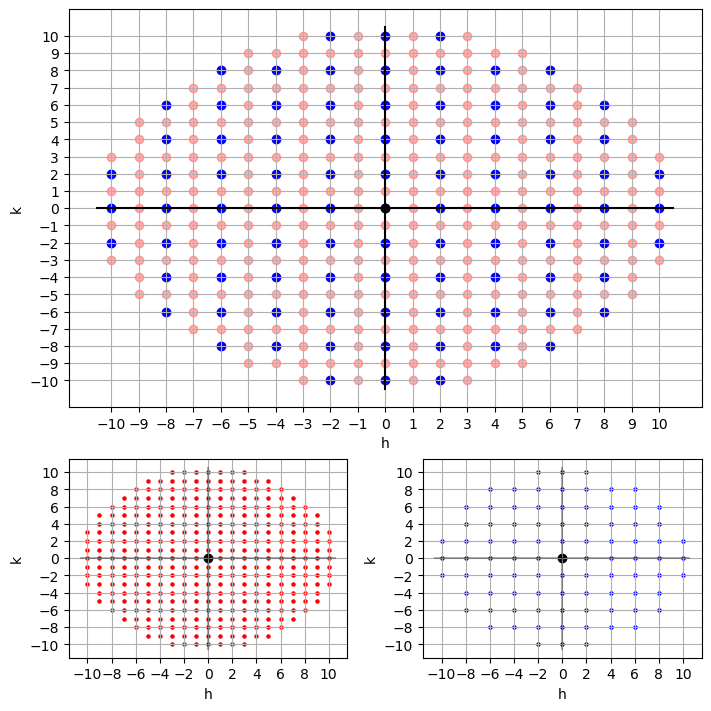

In [65]:
import matplotlib.pyplot as plt
#all points
recip_pts_zero_all = [pt[0] for pt in recip_pts if pt[0][index] == 0]
ind_pnt_x, ind_pnt_y = [pt[view_index[0]] for pt in recip_pts_zero_all], [pt[view_index[1]] for pt in recip_pts_zero_all]

#symm allowed points
recip_pts_zero_allow = [pt[0] for pt in allow_rec_pts if pt[0][index] == 0]
ind_pnt_allow_x, ind_pnt_allow_y = [pt[view_index[0]] for pt in recip_pts_zero_allow], [pt[view_index[1]] for pt in recip_pts_zero_allow]

#special positions
recip_pts_zero_allow_spec = [pt[0] for pt in allow_spec_rec_pts if pt[0][index] == 0]
ind_pnt_allow_spec_x, ind_pnt_allow_spec_y = [pt[view_index[0]] for pt in recip_pts_zero_allow_spec], [pt[view_index[1]] for pt in recip_pts_zero_allow_spec]

#plot the reciprocal points
fig =plt.figure(figsize=(7, 7), layout="constrained")
spec =fig.add_gridspec(2, 2)
spec.set_height_ratios([2,1]) # to change relative height of the rows

ax0 =fig.add_subplot(spec[0, :])
ax10 =fig.add_subplot(spec[1, 0])
ax11 =fig.add_subplot(spec[1, 1])

ax0.scatter(ind_pnt_x, ind_pnt_y, color='r', alpha=0.3,), ax0.set_xlabel(label[0]), ax0.set_ylabel(label[1])
ax0.scatter(ind_pnt_allow_x, ind_pnt_allow_y, c='b'), ax0.set_xlabel(label[0]), ax0.set_ylabel(label[1])
ax0.set_xticks(np.arange(min(ind_pnt_allow_x), max(ind_pnt_allow_x)+1, 1))
ax0.set_yticks(np.arange(min(ind_pnt_allow_x), max(ind_pnt_allow_x)+1, 1))
ax0.scatter(0,0,c='black'), ax0.plot([-10.5,10.5],[0,0], c='black'), ax0.plot([0,0],[-10.5,10.5], c='black')
ax0.grid(True)

ax10.scatter(ind_pnt_x, ind_pnt_y, color='r',  marker='o', s=5), ax10.set_xlabel(label[0]), ax10.set_ylabel(label[1])
ax10.set_xticks(np.arange(min(ind_pnt_allow_x), max(ind_pnt_allow_x)+1, 2))
ax10.set_yticks(np.arange(min(ind_pnt_allow_x), max(ind_pnt_allow_x)+1, 2))
ax10.scatter(0,0,c='black'), ax10.plot([-10.5,10.5],[0,0], c='black', alpha=0.3), ax10.plot([0,0],[-10.5,10.5], c='black', alpha=0.3)
ax10.grid(True)


ax11.scatter(ind_pnt_allow_x, ind_pnt_allow_y, c='b', marker='o', s=5), ax11.set_xlabel(label[0]), ax11.set_ylabel(label[1])
ax11.set_xticks(np.arange(min(ind_pnt_allow_x), max(ind_pnt_allow_x)+1, 2))
ax11.set_yticks(np.arange(min(ind_pnt_allow_x), max(ind_pnt_allow_x)+1, 2))
ax11.scatter(0,0,c='black'), ax11.plot([-10.5,10.5],[0,0], c='black', alpha=0.3), ax11.plot([0,0],[-10.5,10.5], c='black', alpha=0.3)
ax11.grid(True)

In [54]:
from pymatgen.analysis.diffraction.tem import TEMCalculator as tem
struct = Structure.from_file('/Users/marco/Desktop/pa-3_special.cif')
abc = tem(voltage = 200, beam_direction = (1, 0, 0), camera_length = 160)
abc.get_plot_2d(struct)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hoverinfo': 'text',
              'marker': {'cmax': 1,
                         'cmin': 0,
                         'color': [0.009182361705370538, 2.2170433380297015e-32,
                                   0.0123995408326189, ..., 7.132013069370628e-33,
                                   3.557322544363516e-33, 0.0],
                         'colorscale': [[0, 'black'], [1, 'white']],
                         'size': 8},
              'mode': 'markers',
              'showlegend': False,
              'text': [(0, 1̅0, 1̅0), (0, 1̅0, 9̅), (0, 1̅0, 8̅), ..., (0, 11, 9),
                       (0, 11, 10), (0, 11, 11)],
              'type': 'scatter',
              'x': [4.012694472087682, 4.012694472087681, 4.01269447208768, ...,
                    -4.413963919296449, -4.413963919296448, -4.413963919296449],
              'y': [4.012694472087681, 3.6114250248789115, 3.2101555776701436,
                    ..., -3.6114250248789115, -4.012694472087679,
                    -4.413963919296448]},
             {'hoverinfo': 'text',
              'marker': {'cmax': 1, 'cmin': 0, 'color': 'white', 'size': 14},
              'mode': 'markers',
              'showlegend': False,
              'text': '(0, 0, 0): Direct beam',
              'type': 'scatter',
              'x': [0],
              'y': [0]}],
    'layout': {'font': {'color': '#7f7f7f', 'size': 14},
               'height': 550,
               'hovermode': 'closest',
               'paper_bgcolor': 'rgba(100,110,110,0.5)',
               'plot_bgcolor': 'black',
               'template': '...',
               'title': {'text': '2D Diffraction Pattern<br>Beam Direction: 100'},
               'width': 550,
               'xaxis': {'range': [-4, 4],
                         'showgrid': False,
                         'showline': False,
                         'showticklabels': False,
                         'ticks': '',
                         'zeroline': False},
               'yaxis': {'range': [-4, 4],
                         'showgrid': False,
                         'showline': False,
                         'showticklabels': False,
                         'ticks': '',
                         'zeroline': False}}
})

If instead we want a 3D visualization

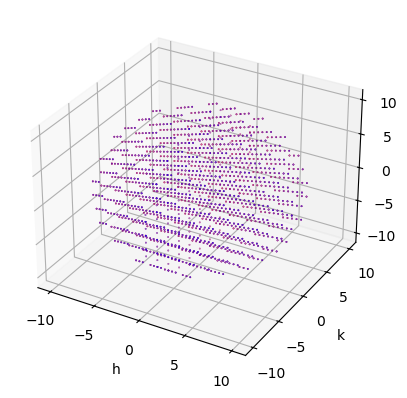

In [99]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

recip_pts_idx = [pt[0] for pt in recip_pts]
hs, ks, ls = [pt[0] for pt in recip_pts_idx], [pt[1] for pt in recip_pts_idx], [pt[2] for pt in recip_pts_idx]

recip_pts_idx_allow = [pt[0] for pt in allow_rec_pts]
hs, ks, ls = [pt[0] for pt in recip_pts_idx_allow], [pt[1] for pt in recip_pts_idx_allow], [pt[2] for pt in recip_pts_idx_allow]

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')
ax.scatter(hs, ks, ls, c='r', alpha=0.6, marker='o', s=0.1), plt.xlabel('h'), plt.ylabel('k')
ax.scatter(hs, ks, ls, c='b', marker='o', s=0.05), plt.xlabel('h'), plt.ylabel('k')
plt.show()

Now we can save the final df

Let's add the space group as master header and then save it

In [ ]:
df.columns = pd.MultiIndex.from_product([[sg], df.columns])
if '/' in sg:
    sg_file = sg.replace('/','_')
else:
    sg_file =sg
df.to_json("bilbao_refl_cond_table_"+
sg_file+".json")
df.to_csv('bilbao_refl_cond_table_'+sg_file+'.csv')
df

Let's consider only the points with a distance value >= than the min_r defined

In [130]:
if min_r_sphere:
    recip_pts = [pt for pt in recip_pts if pt[1] >= min_r_sphere]

Let's print the reciprocal points. They contains:
 - 1 the coodinates in the reciprocal space of each point (h,k,l indexes)
 - 2 the modulus of the scattering vector, $g_{hkl}$, also called $s_{hkl}$
 - 3 the hkl family indices

In [131]:
recip_pts[:5]

[(array([-1., -1., -1.]), 0.15000000000000002, 0, array([-1., -1., -1.])),
 (array([-1., -1., -2.]), 0.17320508075688776, 0, array([-1., -1., -2.])),
 (array([-1., -1., -3.]), 0.20615528128088303, 0, array([-1., -1., -3.])),
 (array([-1., -1., -4.]), 0.24494897427831783, 0, array([-1., -1., -4.])),
 (array([-1., -1., -5.]), 0.2872281323269014, 0, array([-1., -1., -5.]))]

define the containers for the peaks info and 2th values

In [132]:
peaks = {}
two_thetas = []

Now let's extract each single information about the reflexes.
We loop over the reciprocal space points and we extract:
 - 1 the coodinates in the reciprocal space of each point (h,k,l indexes)
 - 2 the modulus of the scattering vector, $g_{hkl}$, also called $s_{hkl}$
 - 3 the hkl family indices  

With these information we will evaluate:
- 1 the $2\theta$ angle corresponding to each $s_{hkl}$
- 2 if the cell is hexagonal, the Miller-Bravais indices
- 3 the family to which each reflex belongs

In [133]:
for hkl, s_hkl, index, _ in sorted(recip_pts, key=lambda i: (i[1], -i[0][0], -i[0][1], -i[0][2])):
    # Force miller indices to be integers.
    hkl = [int(round(i)) for i in hkl]

    #evaluate the 2theta positions for heach scattering vector
    if s_hkl != 0:  
        d_hkl = 1 / s_hkl
        # Bragg condition
        theta = asin(wavelength * s_hkl / 2)
        two_theta = degrees(2 * theta)

        if is_hex:
            # Use Miller-Bravais indices for hexagonal lattices.
            hkl = (hkl[0], hkl[1], -hkl[0] - hkl[1], hkl[2])
        
        # Deal with floating point precision issues.
        index = np.where(
            np.abs(np.subtract(two_thetas, two_theta))
            < TWO_THETA_TOL)
        
        if len(index[0]) > 0:
            peaks[two_thetas[index[0][0]]][0] += 1.0
            peaks[two_thetas[index[0][0]]][1].append(tuple(hkl))
        else:
            peaks[two_theta] = [1.0, [tuple(hkl)], d_hkl]
            two_thetas.append(two_theta)

Let's see what has been created.  
**peaks** it's a dictionary which contains:   

- $2 \theta$ angle of the observed reflections. This is also the key of each entry  
- a list object containing:  
        - the multiplicity of the reflection  
        - the list of the reflection indexes  
        - the dhkl value

In [134]:
print("2theta - multiplicity - reflexes indexes - ?\n------------------------------------------------")
for key in list(peaks.keys())[:5]:
    print(key, peaks[key])

2theta - multiplicity - reflexes indexes - ?
------------------------------------------------
4.426340171106051 [2.0, [(0, 0, 1), (0, 0, -1)], 20.0]
8.859301978849034 [6.0, [(1, 0, 0), (0, 1, 0), (0, 0, 2), (0, 0, -2), (0, -1, 0), (-1, 0, 0)], 10.0]
9.907475128319865 [8.0, [(1, 0, 1), (1, 0, -1), (0, 1, 1), (0, 1, -1), (0, -1, 1), (0, -1, -1), (-1, 0, 1), (-1, 0, -1)], 8.944271909999157]
12.541490027824013 [12.0, [(1, 1, 0), (1, 0, 2), (1, 0, -2), (1, -1, 0), (0, 1, 2), (0, 1, -2), (0, -1, 2), (0, -1, -2), (-1, 1, 0), (-1, 0, 2), (-1, 0, -2), (-1, -1, 0)], 7.071067811865474]
13.305596748476821 [10.0, [(1, 1, 1), (1, 1, -1), (1, -1, 1), (1, -1, -1), (0, 0, 3), (0, 0, -3), (-1, 1, 1), (-1, 1, -1), (-1, -1, 1), (-1, -1, -1)], 6.666666666666666]


while $2\theta$ is simply a collection of the 2 thetas angles at which the reflections were observed.

In [42]:
two_thetas[:5]

[8.859301978849034,
 12.541490027824013,
 15.37557363153954,
 17.77211858772413,
 19.889995348050387]

We can now make a dataframe to then save a .csv file

In [109]:
peaks_df = pd.DataFrame.from_dict(peaks, orient='index', columns=['multiplicity','indices','dhkl'])
peaks_df.insert(0,'2theta', peaks_df.index)
peaks_df = peaks_df.reset_index(drop=True)
peaks_df

,2theta,multiplicity,indices,?
0,8.859302,6.0,"[(1, 0, 0), (0, 1, 0), (0, 0, 1), (0, 0, -1), ...",10.000000
1,12.541490,12.0,"[(1, 1, 0), (1, 0, 1), (1, 0, -1), (1, -1, 0),...",7.071068
2,15.375574,8.0,"[(1, 1, 1), (1, 1, -1), (1, -1, 1), (1, -1, -1...",5.773503
3,17.772119,6.0,"[(2, 0, 0), (0, 2, 0), (0, 0, 2), (0, 0, -2), ...",5.000000
4,19.889995,24.0,"[(2, -1, 0), (1, 0, 2), (0, 1, 2), (0, -1, -2)...",4.472136
...,...,...,...,...
89,105.345087,72.0,"[(9, 5, 0), (9, 4, 3), (9, 4, -3), (9, 3, 4), ...",0.971286
90,106.055149,72.0,"[(9, 5, 1), (9, 5, -1), (9, 1, 5), (9, 1, -5),...",0.966736
91,106.767754,32.0,"[(10, 2, 2), (10, 2, -2), (10, -2, 2), (10, -2...",0.962250
92,107.483039,72.0,"[(10, 3, 0), (10, 0, 3), (10, 0, -3), (10, -3,...",0.957826


We can save it 

In [110]:
peaks_df.to_csv('hkl_extraction.csv')

Now, if u want, let's extract the unique families from the reflexes.

In [92]:
for k in sorted(peaks.keys()):
    y4_uniq_fam = get_unique_families(peaks[k][1])
y4_uniq_fam

{(9, 5, 2): 48, (10, 3, 1): 48, (7, 6, 5): 48}

Ok now let's extract all the data and build a file containing everything in separated columns

In [73]:
x_2th = []
y1_refl = []
y2_mult = []
y3_fam = []
y4_uniq_fam = []

hkls = []
d_hkls = []
for k in sorted(peaks.keys()):
    print(k)
    x_2th.append(k)
    peak_data = peaks[k]
    print(peak_data)
    y1_refl = peak_data[1]
    y2_mult.append(peak_data[0])
    y3_fam = peak_data[1]
    y4_uniq_fam = get_unique_families(peak_data[1])
    #print(f'peaks: {v}, peak_dict: {k}, families: {fam}')

    hkls.append(
        [{"hkl": hkl, "multiplicity": mult} for hkl, mult in fam.items()]
    )
    d_hkls.append(peak_data[2])

8.859301978849034
[6.0, [(1, 0, 0), (0, 1, 0), (0, 0, 1), (0, 0, -1), (0, -1, 0), (-1, 0, 0)], 10.0]
12.541490027824013
[12.0, [(1, 1, 0), (1, 0, 1), (1, 0, -1), (1, -1, 0), (0, 1, 1), (0, 1, -1), (0, -1, 1), (0, -1, -1), (-1, 1, 0), (-1, 0, 1), (-1, 0, -1), (-1, -1, 0)], 7.071067811865474]
15.37557363153954
[8.0, [(1, 1, 1), (1, 1, -1), (1, -1, 1), (1, -1, -1), (-1, 1, 1), (-1, 1, -1), (-1, -1, 1), (-1, -1, -1)], 5.773502691896256]
17.77211858772413
[6.0, [(2, 0, 0), (0, 2, 0), (0, 0, 2), (0, 0, -2), (0, -2, 0), (-2, 0, 0)], 5.0]
19.889995348050387
[24.0, [(2, -1, 0), (1, 0, 2), (0, 1, 2), (0, -1, -2), (-1, 0, -2), (-2, 1, 0), (2, 1, 0), (2, 0, 1), (2, 0, -1), (1, 2, 0), (1, 0, -2), (1, -2, 0), (0, 2, 1), (0, 2, -1), (0, 1, -2), (0, -1, 2), (0, -2, 1), (0, -2, -1), (-1, 2, 0), (-1, 0, 2), (-1, -2, 0), (-2, 0, 1), (-2, 0, -1), (-2, -1, 0)], 4.47213595499958]
21.810607528957615
[24.0, [(2, 1, 1), (2, 1, -1), (2, -1, 1), (2, -1, -1), (1, 2, 1), (1, 2, -1), (1, 1, 2), (1, 1, -2), (1, -1, 

In [84]:
print(y1_refl[:5] , y2_mult[:5])

[(5, 2, 9), (2, 5, 9), (-2, -5, -9), (-5, -2, -9), (10, 3, 1)] [6.0, 12.0, 8.0, 6.0, 24.0]


In [ ]:
peaks.